In [15]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/final_project/'
MODEL_DIR = BASE + 'models/'

train_df = pd.read_csv(BASE + 'df_train.csv')
val_df   = pd.read_csv(BASE + 'df_val.csv')
test_df  = pd.read_csv(BASE + 'df_test.csv')

# Load saved TF-IDF vectorizer
tfidf = joblib.load(MODEL_DIR + 'tfidf_vectorizer.pkl')

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)
print("TF-IDF vectorizer loaded!")

Mounted at /content/drive
Train: (5928, 31)
Val  : (1270, 31)
Test : (1271, 31)
TF-IDF vectorizer loaded!


In [16]:
# Prepare features
from scipy.sparse import hstack, csr_matrix

# Text features via TF-IDF
X_train_tfidf = tfidf.transform(train_df['text_processed'].fillna(''))
X_val_tfidf   = tfidf.transform(val_df['text_processed'].fillna(''))
X_test_tfidf  = tfidf.transform(test_df['text_processed'].fillna(''))

# Tabular features
tabular_features = [
    'customer_age', 'channel_encoded', 'gender_encoded',
    'product_encoded', 'ticket_age_days',
    'word_count', 'char_count', 'sentiment_score'
]

X_train_tab = csr_matrix(train_df[tabular_features].fillna(0).values)
X_val_tab   = csr_matrix(val_df[tabular_features].fillna(0).values)
X_test_tab  = csr_matrix(test_df[tabular_features].fillna(0).values)

# Combined features (TF-IDF + tabular)
X_train = hstack([X_train_tfidf, X_train_tab])
X_val   = hstack([X_val_tfidf,   X_val_tab])
X_test  = hstack([X_test_tfidf,  X_test_tab])

# Targets
y_train_type     = train_df['ticket_type_encoded']
y_val_type       = val_df['ticket_type_encoded']
y_test_type      = test_df['ticket_type_encoded']

y_train_priority = train_df['ticket_priority_encoded']
y_val_priority   = val_df['ticket_priority_encoded']
y_test_priority  = test_df['ticket_priority_encoded']

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

X_train shape: (5928, 5008)
X_val shape  : (1270, 5008)
X_test shape : (1271, 5008)


In [17]:
# evaluation helper function
from sklearn.metrics import (
    accuracy_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load label encoders
le_type     = joblib.load(MODEL_DIR + 'le_type.pkl')
le_priority = joblib.load(MODEL_DIR + 'le_priority.pkl')

def evaluate_model(model, X_val, y_val, label_encoder, model_name, target_name):
    """Evaluate a classifier and print full report"""
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    acc     = accuracy_score(y_val, y_pred)
    f1_mac  = f1_score(y_val, y_pred, average='macro')
    f1_wt   = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_prob, multi_class='ovr', average='macro')

    print(f"\n{'='*55}")
    print(f"MODEL : {model_name}  |  TARGET : {target_name}")
    print(f"{'='*55}")
    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 Macro        : {f1_mac:.4f}")
    print(f"F1 Weighted     : {f1_wt:.4f}")
    print(f"ROC-AUC (macro) : {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_val, y_pred,
                                target_names=label_encoder.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'{model_name} — {target_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'target': target_name,
            'accuracy': acc, 'f1_macro': f1_mac,
            'f1_weighted': f1_wt, 'roc_auc': roc_auc}

print("Evaluation function ready!")

Evaluation function ready!


Training Logistic Regression...
Training complete!

MODEL : Logistic Regression  |  TARGET : Ticket Type
Accuracy        : 0.1953
F1 Macro        : 0.1820
F1 Weighted     : 0.1834
ROC-AUC (macro) : 0.4966

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.12      0.14       245
Cancellation request       0.20      0.28      0.23       254
     Product inquiry       0.18      0.06      0.09       246
      Refund request       0.21      0.29      0.24       263
     Technical issue       0.20      0.22      0.21       262

            accuracy                           0.20      1270
           macro avg       0.19      0.19      0.18      1270
        weighted avg       0.19      0.20      0.18      1270



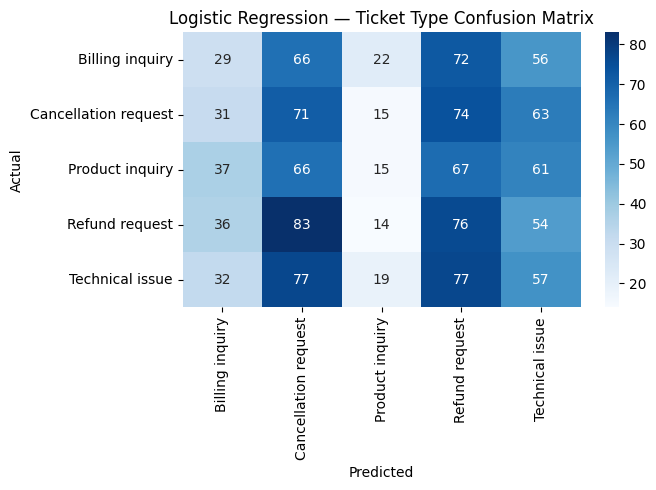


MODEL : Logistic Regression  |  TARGET : Ticket Priority
Accuracy        : 0.2496
F1 Macro        : 0.2416
F1 Weighted     : 0.2416
ROC-AUC (macro) : 0.5049

Classification Report:
              precision    recall  f1-score   support

    Critical       0.23      0.35      0.28       336
        High       0.28      0.33      0.30       307
         Low       0.27      0.16      0.21       292
      Medium       0.22      0.15      0.18       335

    accuracy                           0.25      1270
   macro avg       0.25      0.25      0.24      1270
weighted avg       0.25      0.25      0.24      1270



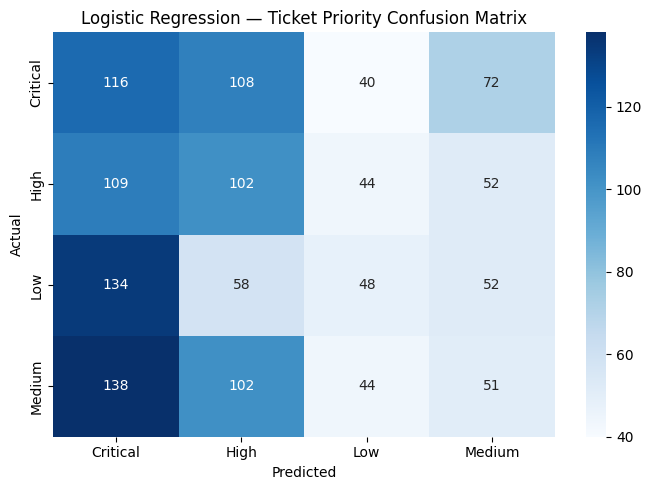

Models saved!


In [18]:
# Baseline1- Logistic Regression
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")

# Ticket Type classifier
lr_type = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=1.0
)
lr_type.fit(X_train, y_train_type)

# Ticket Priority classifier
lr_priority = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=1.0
)
lr_priority.fit(X_train, y_train_priority)

print("Training complete!")

# Evaluate
results = []
results.append(evaluate_model(lr_type,     X_val, y_val_type,
                               le_type,     'Logistic Regression', 'Ticket Type'))
results.append(evaluate_model(lr_priority, X_val, y_val_priority,
                               le_priority, 'Logistic Regression', 'Ticket Priority'))

# Save model
joblib.dump(lr_type,     MODEL_DIR + 'lr_type.pkl')
joblib.dump(lr_priority, MODEL_DIR + 'lr_priority.pkl')
print("Models saved!")

Training Naive Bayes...
Training complete!

MODEL : Naive Bayes  |  TARGET : Ticket Type
Accuracy        : 0.2181
F1 Macro        : 0.2177
F1 Weighted     : 0.2180
ROC-AUC (macro) : 0.5189

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.21      0.21       245
Cancellation request       0.19      0.19      0.19       254
     Product inquiry       0.22      0.22      0.22       246
      Refund request       0.22      0.22      0.22       263
     Technical issue       0.25      0.26      0.25       262

            accuracy                           0.22      1270
           macro avg       0.22      0.22      0.22      1270
        weighted avg       0.22      0.22      0.22      1270



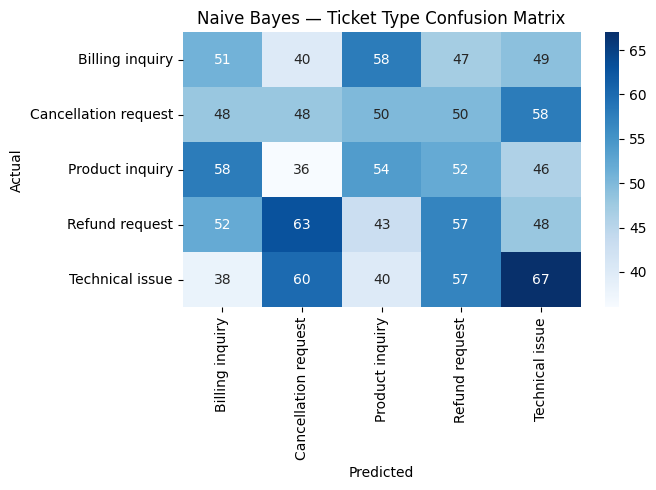


MODEL : Naive Bayes  |  TARGET : Ticket Priority
Accuracy        : 0.2465
F1 Macro        : 0.2453
F1 Weighted     : 0.2460
ROC-AUC (macro) : 0.5066

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.27      0.26       336
        High       0.22      0.20      0.21       307
         Low       0.23      0.26      0.25       292
      Medium       0.28      0.25      0.26       335

    accuracy                           0.25      1270
   macro avg       0.25      0.25      0.25      1270
weighted avg       0.25      0.25      0.25      1270



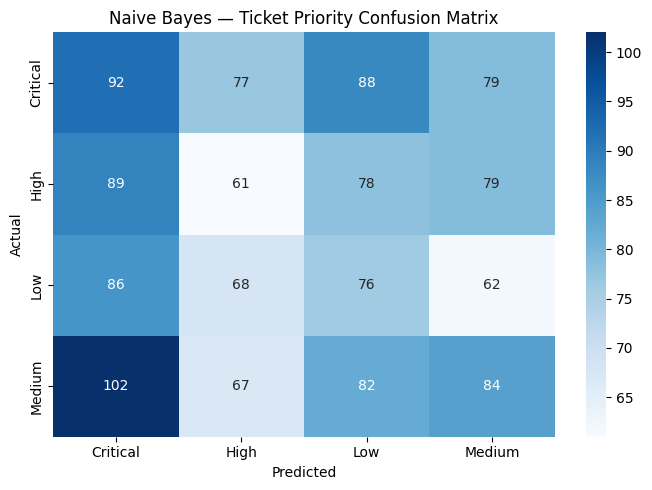

Models saved!


In [19]:
# BAseline2-Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# Naive Bayes needs non-negative features
# Re-prepare with MinMaxScaled tabular features
scaler = MinMaxScaler()
X_train_tab_scaled = csr_matrix(scaler.fit_transform(
    train_df[tabular_features].fillna(0).values))
X_val_tab_scaled   = csr_matrix(scaler.transform(
    val_df[tabular_features].fillna(0).values))

X_train_nb = hstack([X_train_tfidf, X_train_tab_scaled])
X_val_nb   = hstack([X_val_tfidf,   X_val_tab_scaled])

print("Training Naive Bayes...")

nb_type = MultinomialNB(alpha=0.1)
nb_type.fit(X_train_nb, y_train_type)

nb_priority = MultinomialNB(alpha=0.1)
nb_priority.fit(X_train_nb, y_train_priority)

print("Training complete!")

results.append(evaluate_model(nb_type,     X_val_nb, y_val_type,
                               le_type,     'Naive Bayes', 'Ticket Type'))
results.append(evaluate_model(nb_priority, X_val_nb, y_val_priority,
                               le_priority, 'Naive Bayes', 'Ticket Priority'))

joblib.dump(nb_type,     MODEL_DIR + 'nb_type.pkl')
joblib.dump(nb_priority, MODEL_DIR + 'nb_priority.pkl')
joblib.dump(scaler,      MODEL_DIR + 'minmax_scaler.pkl')
print("Models saved!")

Training Decision Tree...
Training complete!

MODEL : Decision Tree  |  TARGET : Ticket Type
Accuracy        : 0.1953
F1 Macro        : 0.1081
F1 Weighted     : 0.1060
ROC-AUC (macro) : 0.5064

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.87      0.31       245
Cancellation request       0.26      0.06      0.10       254
     Product inquiry       0.26      0.03      0.06       246
      Refund request       0.35      0.03      0.06       263
     Technical issue       0.08      0.01      0.01       262

            accuracy                           0.20      1270
           macro avg       0.23      0.20      0.11      1270
        weighted avg       0.23      0.20      0.11      1270



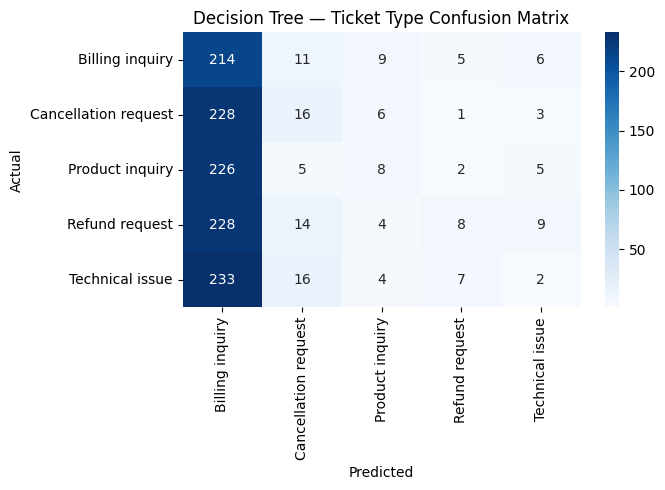


MODEL : Decision Tree  |  TARGET : Ticket Priority
Accuracy        : 0.2268
F1 Macro        : 0.1042
F1 Weighted     : 0.0973
ROC-AUC (macro) : 0.4943

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.01      0.02       336
        High       0.04      0.00      0.01       307
         Low       0.23      0.96      0.37       292
      Medium       0.25      0.01      0.02       335

    accuracy                           0.23      1270
   macro avg       0.19      0.25      0.10      1270
weighted avg       0.20      0.23      0.10      1270



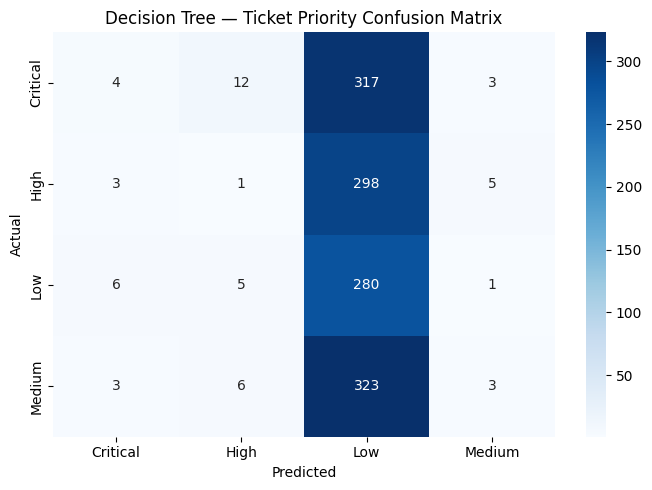

Models saved!


In [20]:
# Baseline3-Decision Tree
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree...")

dt_type = DecisionTreeClassifier(
    max_depth=20,
    class_weight='balanced',
    random_state=42
)
dt_type.fit(X_train, y_train_type)

dt_priority = DecisionTreeClassifier(
    max_depth=20,
    class_weight='balanced',
    random_state=42
)
dt_priority.fit(X_train, y_train_priority)

print("Training complete!")

results.append(evaluate_model(dt_type,     X_val, y_val_type,
                               le_type,     'Decision Tree', 'Ticket Type'))
results.append(evaluate_model(dt_priority, X_val, y_val_priority,
                               le_priority, 'Decision Tree', 'Ticket Priority'))

joblib.dump(dt_type,     MODEL_DIR + 'dt_type.pkl')
joblib.dump(dt_priority, MODEL_DIR + 'dt_priority.pkl')
print("Models saved!")

In [21]:
# Baseline Comparison
results_df = pd.DataFrame(results)

print("\n" + "=" * 65)
print("BASELINE MODEL COMPARISON")
print("=" * 65)
print(results_df[['model','target','accuracy','f1_macro','roc_auc']]
      .sort_values('f1_macro', ascending=False)
      .to_string(index=False))

# Save results
results_df.to_csv(BASE + 'baseline_results.csv', index=False)



BASELINE MODEL COMPARISON
              model          target  accuracy  f1_macro  roc_auc
        Naive Bayes Ticket Priority  0.246457  0.245250 0.506555
Logistic Regression Ticket Priority  0.249606  0.241616 0.504915
        Naive Bayes     Ticket Type  0.218110  0.217691 0.518895
Logistic Regression     Ticket Type  0.195276  0.182009 0.496632
      Decision Tree     Ticket Type  0.195276  0.108082 0.506433
      Decision Tree Ticket Priority  0.226772  0.104230 0.494324


### XGBoost Models

Now, let's train XGBoost models for both classification (Ticket Type and Priority) and regression (Time to Resolution).